In [1]:
#import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load in the data sert
df = pd.read_csv('Assignment-data-diabetes.csv')

In [3]:
#print the initial few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Here we are printing the null values of each coulmn if there are any

In [4]:
#print all null values if any
print(f'Missing values in the dataframe are :: \n{df.isna().sum()}')

Missing values in the dataframe are :: 
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# As per the above result we can conclude that there are no Null values in the data,lets look how the values are distributed for each feature

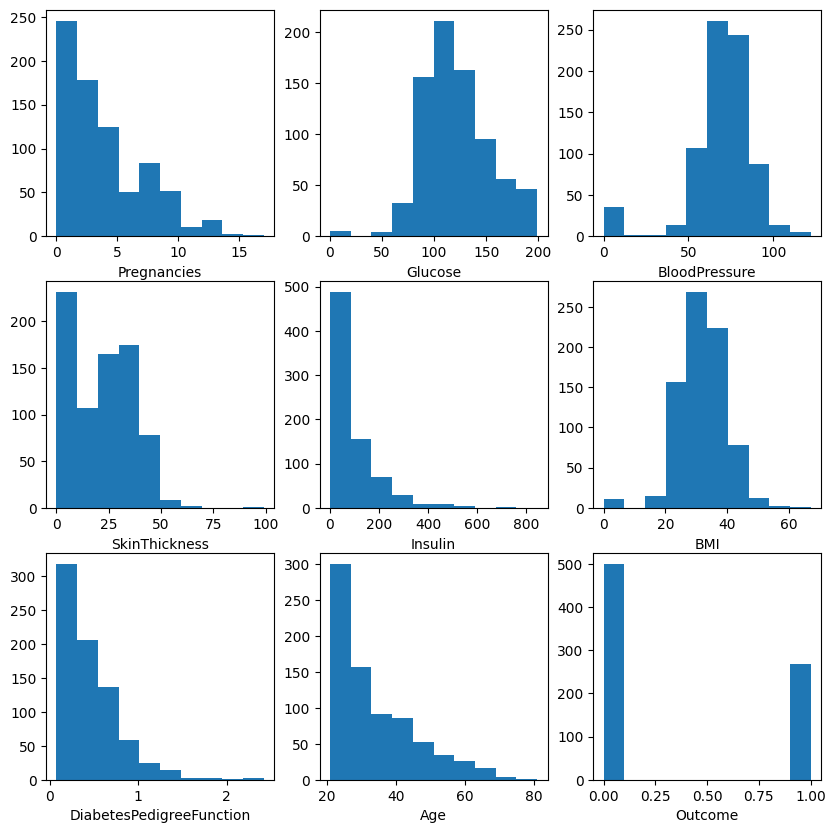

In [5]:
i=0
fig,ax=plt.subplots(ncols=3,nrows=3,figsize=(10,10))
for row in range(3):
    for col in range(3):
         ax[row,col].hist(data=df,x=df.columns[i])
        #  sns.kdeplot(df[df.columns[i]],ax=ax[row,col],color='red')
         ax[row,col].set_xlabel(df.columns[i])
         i=i+1
         plt.plot()

## From the above plots we can see the feature like Glucose , BMI , Insulin, Skin Thickness and Blood Pressure have got zero values. As per medical science, these values cannot be zeros. We have do some cleaning here.

In [6]:
#number rows which are zero for 

# Glucose
df.loc[df['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [7]:
# BMI
df.loc[df['BMI']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.0,0.232,54,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
684,5,136,82,0,0,0.0,0.640,69,0


In [8]:
# Skin thickness
df.loc[df['SkinThickness']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
762,9,89,62,0,0,22.5,0.142,33,0


In [9]:
# Insulin
df.loc[df['Insulin']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


In [10]:
# Blood Pressure
df.loc[df['BloodPressure']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1
222,7,119,0,0,0,25.2,0.209,37,0
261,3,141,0,0,0,30.0,0.761,27,1


# Lets Draw a correlation matrix of the dataset

In [11]:
corr=df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


# Lets plot a correlation Matrix after removing all the zero values from featues excluding outcome



In [12]:
df1=df.copy()

In [13]:
sampls_cols=['Glucose' , 'BMI' , 'Insulin', 'SkinThickness' , 'BloodPressure']
for col in sampls_cols:
    df1.drop(df1.loc[df1[col]==0].index,axis=0,inplace=True)

In [14]:
corr=df1.corr()
corr.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.198291,0.213355,0.093209,0.078984,-0.025347,0.007562,0.679608,0.256566
Glucose,0.198291,1.000000,0.210027,0.198856,0.581223,0.209516,0.140180,0.343641,0.515703
BloodPressure,0.213355,0.210027,1.000000,0.232571,0.098512,0.304403,-0.015971,0.300039,0.192673
SkinThickness,0.093209,0.198856,0.232571,1.000000,0.182199,0.664355,0.160499,0.167761,0.255936
Insulin,0.078984,0.581223,0.098512,0.182199,1.000000,0.226397,0.135906,0.217082,0.301429
BMI,-0.025347,0.209516,0.304403,0.664355,0.226397,1.000000,0.158771,0.069814,0.270118
DiabetesPedigreeFunction,0.007562,0.140180,-0.015971,0.160499,0.135906,0.158771,1.000000,0.085029,0.209330
Age,0.679608,0.343641,0.300039,0.167761,0.217082,0.069814,0.085029,1.000000,0.350804
Outcome,0.256566,0.515703,0.192673,0.255936,0.301429,0.270118,0.209330,0.350804,1.000000


# We can see Glucose and insulin are higly correlated and so is Skin Thickness and BMI. We can also see Blood pressure is not that correlated to any other feature. So lets remove all rows with 0 Blood Pressure

In [15]:

df.drop(df.loc[df['BloodPressure']==0].index,axis=0,inplace=True)

# Lets Look for the other columns with zero values now

In [16]:
# Glucose
df.loc[df['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [17]:
# BMI
df.loc[df['BMI']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.0,0.232,54,1
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
684,5,136,82,0,0,0.0,0.640,69,0


In [18]:
# Skin thickness
df.loc[df['SkinThickness']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0
11,10,168,74,0,0,38.0,0.537,34,1
...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
762,9,89,62,0,0,22.5,0.142,33,0


In [19]:
# Insulin
df.loc[df['Insulin']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
9,8,125,96,0,0,0.0,0.232,54,1
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


## We know that Insulin and Glucose are highly Correlated to each other, lets remove the rows, where both these values are zero. Also lets do the same for BMI and Skin thickness.

In [20]:

df.drop(df.loc[(df['BMI']==0)&(df['SkinThickness']==0)].index,axis=0,inplace=True)

In [21]:

df.drop(df.loc[(df['Glucose']==0)&(df['Insulin']==0)].index,axis=0,inplace=True)

In [22]:
# Glucose
df.loc[df['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
182,1,0,74,20,23,27.7,0.299,21,0


In [23]:
# Lets drop this value also

df.drop(df.loc[(df['Glucose']==0)].index,axis=0,inplace=True)

# Glucose
df.loc[df['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [24]:
# BMI
df.loc[df['BMI']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0


In [25]:
# Lets drop These value also

df.drop(df.loc[(df['BMI']==0)].index,axis=0,inplace=True)

# Glucose
df.loc[df['BMI']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [26]:
# Skin thickness
df.loc[df['SkinThickness']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
10,4,110,92,0,0,37.6,0.191,30,0
11,10,168,74,0,0,38.0,0.537,34,1
12,10,139,80,0,0,27.1,1.441,57,0
...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
762,9,89,62,0,0,22.5,0.142,33,0


In [27]:
# Insulin
df.loc[df['Insulin']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


## Lets handle the missing values of Skin Thickness and BMI

In [28]:
# Lets Arrange the dataset for Skin Thickness and BMI in ascending order of BMI
# Set option to display all rows
pd.set_option('display.max_rows', None)
df=df.reset_index().drop('index',axis=1)
df2=df.copy()

## here we arrange the data in increasing order of the Glucose value and then sample the data to 8 rows. Then take the avg value of the Insulin of the 8 samples(excluding zeros) and replacing the result to the zero values

In [29]:
# (Optional) Reset to default later if needed
pd.reset_option('display.max_rows')

r_prev=0
for r in range(8,724,8):    
    sample_df=df2.sort_values('Glucose')[r_prev:r]
    indices=[]
    vals=0
    for sample_index in list(sample_df.index):
        current_val=sample_df['Insulin'].loc[sample_index]
        if current_val==0:
            indices.append(sample_index)
        else:
            vals =vals+current_val
        avg_valu=vals/(8-len(indices))
    if avg_valu==0:
        print(f'Avg Value:{avg_valu}')
    for sample_index in indices:
        df2['Insulin'].loc[sample_index]=int(avg_valu)
    r_prev=r

sample_df=df2.sort_values('Glucose')[r_prev:724]
indices=[]
vals=0
for sample_index in list(sample_df.index):
    current_val=sample_df['Insulin'].loc[sample_index]
    if current_val==0:
        indices.append(sample_index)
    else:
        vals =vals+current_val
    avg_valu=vals/((724-r_prev)-len(indices))
if avg_valu==0:
    print(f'Avg Value:{avg_valu}')
for sample_index in indices:
    df2['Insulin'].loc[sample_index]=int(avg_valu)
 

## Lets do the same for BMI and Skin Thickness

In [30]:
# (Optional) Reset to default later if needed
pd.reset_option('display.max_rows')

r_prev=0
for r in range(6,724,6):    
    sample_df=df2.sort_values('BMI')[r_prev:r]
    indices=[]
    vals=0
    for sample_index in list(sample_df.index):
        current_val=sample_df['SkinThickness'].loc[sample_index]
        if current_val==0:
            indices.append(sample_index)
        else:
            vals =vals+current_val
        avg_valu=vals/(6-len(indices))
    if avg_valu==0:
        print(f'Avg Value:{avg_valu}')
    for sample_index in indices:
        df2['SkinThickness'].loc[sample_index]=int(avg_valu)
    r_prev=r

sample_df=df2.sort_values('BMI')[r_prev:724]
indices=[]
vals=0
for sample_index in list(sample_df.index):
    current_val=sample_df['SkinThickness'].loc[sample_index]
    if current_val==0:
        indices.append(sample_index)
    else:
        vals =vals+current_val
    avg_valu=vals/((724-r_prev)-len(indices))
if avg_valu==0:
    print(f'Avg Value:{avg_valu}')
for sample_index in indices:
    df2['SkinThickness'].loc[sample_index]=int(avg_valu)
 

In [31]:
df2.loc[df2['SkinThickness']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


## Lets draw our distribution again now

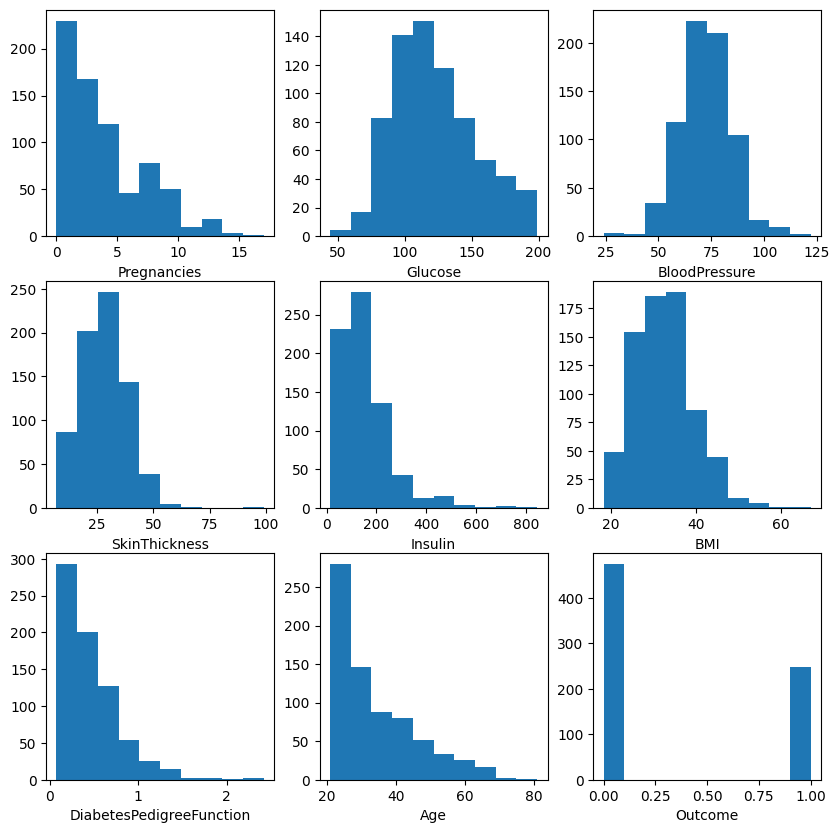

In [32]:
i=0
fig,ax=plt.subplots(ncols=3,nrows=3,figsize=(10,10))
for row in range(3):
    for col in range(3):
         ax[row,col].hist(data=df2,x=df.columns[i])
         ax[row,col].set_xlabel(df2.columns[i])
         i=i+1
         plt.plot()

## Lets draw Boxplots for the features

<Axes: xlabel='SkinThickness'>

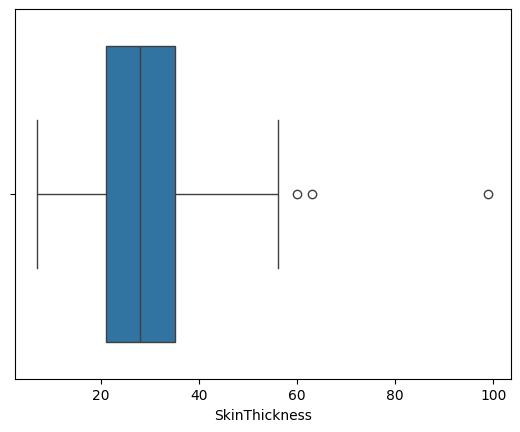

In [33]:
sns.boxplot(data=df2,x='SkinThickness')

In [34]:
# Lets remove the outlier for Skin 
df2.loc[df2['SkinThickness']>90]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
544,2,197,70,99,408,34.7,0.575,62,1


<Axes: xlabel='BMI'>

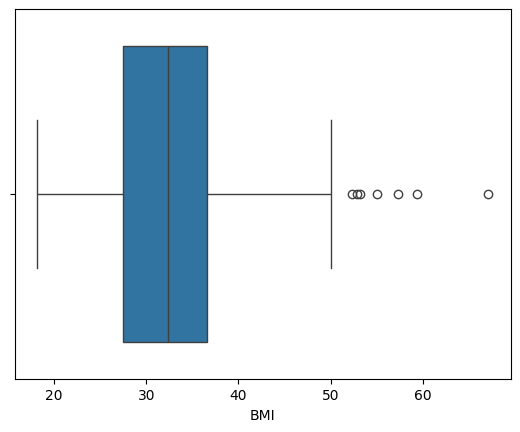

In [35]:
sns.boxplot(data=df2,x='BMI')

<Axes: xlabel='Insulin'>

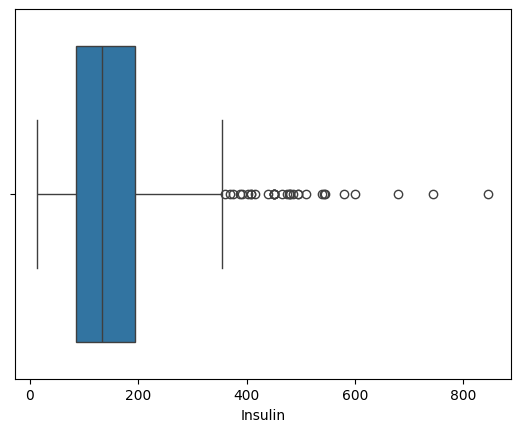

In [36]:
sns.boxplot(data=df2,x='Insulin')

<Axes: xlabel='BloodPressure'>

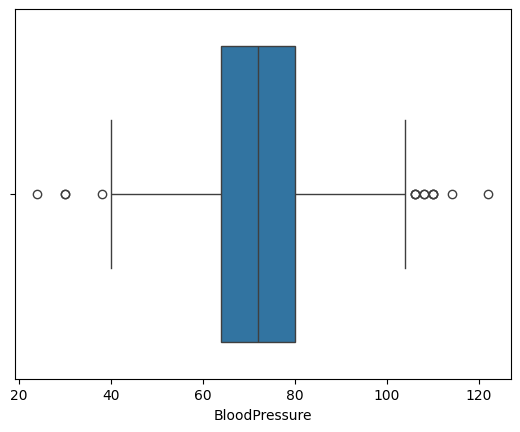

In [37]:
sns.boxplot(data=df2,x='BloodPressure')

In [38]:
df2.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000,724.000000
mean,3.866022,121.882597,72.400552,28.535912,154.792818,32.467127,0.474765,33.350829,0.343923
std,3.362803,30.750030,12.379870,9.944387,102.943074,6.888941,0.332315,11.765393,0.475344
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,21.000000,86.000000,27.500000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,133.000000,32.400000,0.379000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,35.000000,194.000000,36.600000,0.627500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## The Insulin values are too skewed to towards the higher values. So we can replace the values above as 194

In [39]:
def insulin(val):
    if val>194:
        return 194
    else:
        return val

df2['Insulin']=df2['Insulin'].apply(insulin)

## Now that we removed all the zero values,lets draw the correlation matrix again and compare with the same on the previous data

In [40]:
corr=df2.corr()
corr.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.134915,0.209668,0.083836,0.108648,0.012342,-0.025996,0.557066,0.224417
Glucose,0.134915,1.000000,0.223331,0.207736,0.659782,0.223276,0.136630,0.263560,0.488384
BloodPressure,0.209668,0.223331,1.000000,0.199908,0.190782,0.287403,-0.000075,0.324897,0.166703
SkinThickness,0.083836,0.207736,0.199908,1.000000,0.187991,0.688264,0.129765,0.104218,0.249459
Insulin,0.108648,0.659782,0.190782,0.187991,1.000000,0.215644,0.079955,0.227564,0.336158
BMI,0.012342,0.223276,0.287403,0.688264,0.215644,1.000000,0.154858,0.020835,0.299375
DiabetesPedigreeFunction,-0.025996,0.136630,-0.000075,0.129765,0.079955,0.154858,1.000000,0.023098,0.184947
Age,0.557066,0.263560,0.324897,0.104218,0.227564,0.020835,0.023098,1.000000,0.245741
Outcome,0.224417,0.488384,0.166703,0.249459,0.336158,0.299375,0.184947,0.245741,1.000000


In [41]:
corr=df1.corr()
corr.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.198291,0.213355,0.093209,0.078984,-0.025347,0.007562,0.679608,0.256566
Glucose,0.198291,1.000000,0.210027,0.198856,0.581223,0.209516,0.140180,0.343641,0.515703
BloodPressure,0.213355,0.210027,1.000000,0.232571,0.098512,0.304403,-0.015971,0.300039,0.192673
SkinThickness,0.093209,0.198856,0.232571,1.000000,0.182199,0.664355,0.160499,0.167761,0.255936
Insulin,0.078984,0.581223,0.098512,0.182199,1.000000,0.226397,0.135906,0.217082,0.301429
BMI,-0.025347,0.209516,0.304403,0.664355,0.226397,1.000000,0.158771,0.069814,0.270118
DiabetesPedigreeFunction,0.007562,0.140180,-0.015971,0.160499,0.135906,0.158771,1.000000,0.085029,0.209330
Age,0.679608,0.343641,0.300039,0.167761,0.217082,0.069814,0.085029,1.000000,0.350804
Outcome,0.256566,0.515703,0.192673,0.255936,0.301429,0.270118,0.209330,0.350804,1.000000


## Train the model using preprocessed Data

## import necessary sklearn functions

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  accuracy_score,classification_report,confusion_matrix,roc_curve,auc

In [43]:
X,y=df2.drop('Outcome',axis=1),df2['Outcome']

In [44]:
#Split the data in to train and Test data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
#Standardize the  Featues
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [46]:
# Train the model in Logistic regression
model=LogisticRegression()

model.fit(X_train,y_train)


LogisticRegression()

In [47]:
# Calculate the model accuracy
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)

print(f'Accuracy of the model is :{accuracy}')



Accuracy of the model is :0.7931034482758621


In [48]:
#Confusion Matrix and Classification Report

print('Confuxion Matrix: \n',confusion_matrix(y_test,y_pred))
print('\nClassication Report: \n',classification_report(y_test,y_pred))

Confuxion Matrix: 
 [[88 14]
 [16 27]]

Classication Report: 
               precision    recall  f1-score   support

           0       0.85      0.86      0.85       102
           1       0.66      0.63      0.64        43

    accuracy                           0.79       145
   macro avg       0.75      0.75      0.75       145
weighted avg       0.79      0.79      0.79       145



## Train the model using unprocessed Data

In [49]:
# Load in the data sert
df = pd.read_csv('Assignment-data-diabetes.csv')
X,y=df.drop('Outcome',axis=1),df['Outcome']

In [50]:
#Split the data in to train and Test data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
#Standardize the  Featues
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [52]:
# Train the model in Logistic regression
model=LogisticRegression()

model.fit(X_train,y_train)


LogisticRegression()

In [53]:
# Calculate the model accuracy
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)

print(f'Accuracy of the model is :{accuracy}')



Accuracy of the model is :0.7532467532467533


In [54]:
#Confusion Matrix and Classification Report

print('Confuxion Matrix: \n',confusion_matrix(y_test,y_pred))
print('\nClassication Report: \n',classification_report(y_test,y_pred))

Confuxion Matrix: 
 [[79 20]
 [18 37]]

Classication Report: 
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



## The Accuracy of the model,when trained on a preproccessed data is 0.7931034482758621 and the accuracy of the model when trained on un processed data is 0.7532467532467533  

## We could find this change in accuracy due to the preprocessing we have done.

### What would go wrong in the lifecycle if preprocessing is skipped?

If the preprocessing is skipped. The best thing we can say is 
      
      "Garbage in Garbage out"
      
The below could be some of the issues that we may face when working on un processed data




1. The model performance may get impact- the model learning from nosiy and inproproper data may lead to improper predictions
2. The models predictions would be biased more due to the Outliers that may be present in the dataset.
3. There could be some categorical data present in the dataset, that could not be interpreted properly by the model and it may lead to issues.
4. This model could not be deployed in production due to this performance issues

### Now, based on your own coding experience (in this lab or elsewhere), explain whether this problem could have been identified or prevented using only normal programming practices. Justify with one concrete example from your own implementation or learning

The problem can be found with normal programming only to certain extend. The perfect solution to problem lies in domain knowledge and programming skills. We should analyse the data, learn  more about it. we have to check of the data is meaningful.

For example: In the assignment we have just done, there were so may rows that had 0 as the value for Insulin and Skin thickness. Normal programming techniques coulnot identify this.Because zero is a valid numerical value. The model will treat 0 as normal value (Actual low value), leading to incorrect patterns learned.I we have domain knowledge, we can understand that 0 insulin levels are biologically implausible, should be treated as missing values, and followed by appropriate imputation or removal.